# Differential Equations 3

In notebooks [Differential_Equations_01_Intro.ipynb](Differential_Equations_01_Intro.ipynb) and [Differential_Equations_02_Why](Differential_Equations_02_Why.ipynb), we saw some examples of differential equations, and analytically solved some simple examples. 

However, there are many many differential equations that are *impossible* to solve analytically. 
 - They have to be solved numerically. 
 
We will now learn how to solve differential equations numerically. 
 - We will start by numerically solving an equation we already know the solution to, so that we can check our method works! 
 - After that we will move on to solve more difficult equations that *require* a numerical approach. 
 
# Contents 
 1. Numerical Solutions to Analytically Solvable Problems 
 2. Differential Equations that *Require* Numerical Methods

#  1. Numerical Solutions to Analytically Solvable Problems 


In [2]:
# Standard Imports 
import matplotlib.pyplot as plt
import numpy as np

# The scipy.integrate.solve_ivp function we will use for solving 
from scipy.integrate import solve_ivp

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


# 1.1 Exponential Growth

Consider the eqn $dN/dt = rN$.

We know from the notebook [Differential_Equations_02_Why.ipynb](Differential_Equations_02_Why.ipynb) that the solution is 

$N = \pm N_0 e^{rt}$

Here we use the `scipy.integrate.solve_ivp` function to numerically integrate the differential equation (given an initial value).

**The `solve_ivp` function ...**
 - Documentation is [here](https://docs.scipy.org/doc/scipy/reference/generated/scipy.integrate.solve_ivp.html#scipy.integrate.solve_ivp)
 - Required arguments are ... `solve_ivp(fun, t_span, y0, ...)`
   - `fun` = $dy/dt$, i.e. the rate of change of the dependent variable(s)
     - For our problem, this is $dN/dt = rN$
     - You need to create a python function for this 
     - It is required to have a signature that looks like `fun(t,y,other_args)`
   - `t_span` = $[t_{\text{start}},t_{\text{end}}]$, i.e. the time range you are interested in
     - For us this doesn't matter too much, so I'll choose $ t_{\text{start}} = 0$ & $t_{\text{end}}=15$
   - `y0` = the initial value(s) for the variable(s)
     - I'll use an initial population of $N_0=25$
     
 - Optional Arguments ...
   - One particularly useful argument you can pass to `solve_ivp` is `solve_ivp(..., args=(other_args,), ...)`, where `other_args` is something that you want to pass into the $dy/dt$ function above.
     - We'll pass in the growth-rate, $r$

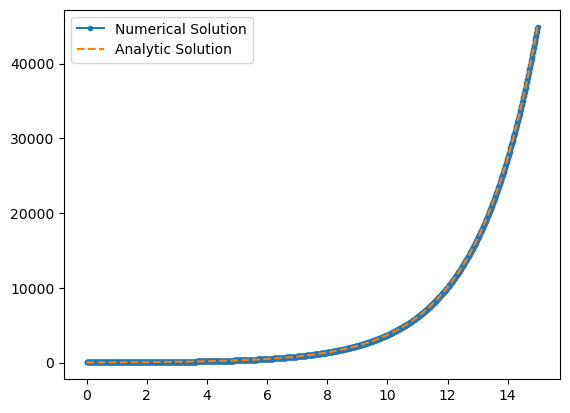

In [68]:
# Consider the eqn dN/dt = rN from the notebook Differential_Equations_02_Why.ipynb
def dNdt(t, y, growth_rate):
    return growth_rate*y

# Define the initial values of N & the growth-rate 
init_popn = [25.0]
growth_rate = 0.5

# Define the time-span over which we want the solution to be calculated 
t_span = [0,15]

# Call the solver 
sol = solve_ivp(dNdt, t_span, init_popn, args=(growth_rate,), dense_output=True )


# Time points for plotting 
t = np.arange(0,15,0.01) 

# Plot the numerical solution 
plt.plot(t, sol.sol(t)[0], '.-', label="Numerical Solution")

# Plot the analytic solution 
#  N = init_popn*np.exp(growth_rate*t)
plt.plot(t, init_popn*np.exp(growth_rate*t), '--', label="Analytic Solution")
_=plt.legend() 



# 1.2 Mass-on-a-Spring

Consider the second order differential equation,  

$ {\frac {\mathrm {d} ^{2}x(t)}{\mathrm {d} t^{2}}} + \omega^2 x = 0 $

In the notebook [Differential_Equations_02_Why.ipynb](Differential_Equations_02_Why.ipynb) we saw that the general solution to this equation can be expressed as

$x(t) =  C\cos{\left(\omega t\right)} + D\sin{\left(\omega t\right)} $

or

$x(t) = E \cos( \omega t + \delta)$


We'd like to use `solve_ivp` again to solve this numerically, but `solve_ivp` only knows about *first-order* differential equations. 

So we have to use a trick to convert our second order differential equation into a set of multiple first-order ODEs ...
 - Define $y_1(t) = x(t)$ & $y_2(t) = \frac{dx(t)}{dt}(t)$
 - Therefore 
   - $\frac{d y_1(t)}{dt} = \frac{d x(t)}{dt} = y_2(t)$
   - $\frac{d y_2(t)}{dt} = \frac{d^2x(t)}{dt^2}(t) = -\omega^2 x(t) = -\omega^2 y_1(t)$
 
Going beyond the general solution considered in [Differential_Equations_02_Why.ipynb](Differential_Equations_02_Why.ipynb), we need to consider some specific *initial conditions* in order to compute the numerical solution ...
 - Let's set $x(t=0) = 0$ and $v_0 = \frac{dx(t=0)}{dt} = 2$.
 - This means that $x_0 = C = 0$ & $v_0=\frac{dx(t=0)}{dt} = D\omega = 2$, i.e. $D=\frac{2}{\omega}$

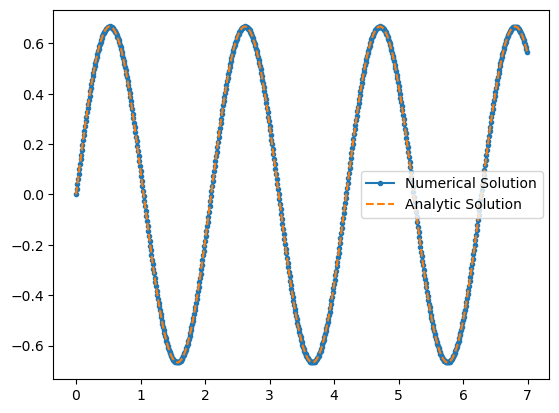

In [71]:
# Consider the eqn dN/dt = rN from the notebook Differential_Equations_02_Why.ipynb
def dydt(t, y, omega):
    # y == ( y1, y2) == ( x , dxdt )
    # dydt = ( dy1/dt, dy2dt ) = ( y2 , - omega^2 y1 )
    return [y[1], -omega**2 * y[0]] # <--> dxdt, 

# Define the values of omega & the initial position & velocity
omega = 3.0
x0, v0 = 0,2

# Define the time-span over which we want the solution to be calculated 
t_span = [0,15]

# Call the solver 
sol = solve_ivp(dydt, t_span, [x0,v0], args=(omega,), dense_output=True )


# An array of time values
t = np.arange(0,7,0.01) 
    
# Plot the numerical solution 
plt.plot(t, sol.sol(t)[0], '.-', label="Numerical Solution")

# Plot the analytic solution 
D = v0/omega
plt.plot(t, D*np.sin( omega * t), '--', label="Analytic Solution")
plt.legend() 



## Exercise (A)

The Logistic Differential Equation is defined as 
\begin{equation}
    \frac{dP}{dt} = rP\left(1 - \frac{P}{K}\right)
\end{equation}
where 
 - $r$ is the growth-rate 
 - $P_0$ is the initial population
 - $P(t)$ is the population as a function of time 
 - $K$ is the *carrying capacity*
See [here](https://math.libretexts.org/Bookshelves/Calculus/Calculus_(OpenStax)/08%3A_Introduction_to_Differential_Equations/8.04%3A_The_Logistic_Equation#:~:text=Definition%3A%20Logistic%20Differential%20Equation,-Let%20K%20represent&text=dPdt%3DrP(1%E2%88%92PK,problem%20for%20P(t).) and [here](https://en.wikipedia.org/wiki/Logistic_function) for more detailed discussions.

1. Use analytic methods to solve this differential equation and show that the solution has the form 
\begin{equation}
    P(t) = \frac{K}{1 + \left(\frac{K - P_0}{P_0}\right)e^{-rt}}
\end{equation}
 N.B. It will probably be useful for you to use the following 
 \begin{equation}
    \int\frac{dP}{P\left(1 - \frac{P}{K}\right)} dP = \int \left( \frac{1}{P} + \frac{1/K}{1 - P/K} \right) dP = \ln|P| - \ln|1 - \frac{P}{K}|
\end{equation}
2. Use `solve_ivp` to solve this equation *numerically*
 - Assume $r=0.5$, $K=5$, $P_0 = 2$
3. Create a plot comparing your analytic & numerical solutions from (1) & (2) respectively.
4. Using the same approach as in Exercise (A) of [Differential_Equations_02_Why.ipynb](Differential_Equations_02_Why.ipynb), use the `ipywidgets.interact` function to make a *dynamic* plot that allows you vary the values of $r$, $K$ & $P_0$ using sliders, and hence compare your analytic & numerical solutions from (1) & (2) as you vary the parameters. 

# 2. Differential Equations that *Require* Numerical Methods

We now examine an equation that cannot be solved (generally) using analytic methods

#### Non-Linear Pendulum Equation:
    
$\frac{d^2 \theta}{dt^2} +\frac{g}{l}\sin{\theta} = 0$

This equation describes the motion of a pendulum with angle $\theta$, 
where $g$ is the acceleration due to gravity and 
$l$ is the length of the pendulum. 

Unlike the small-angle approximation (which leads to a linear and solvable equation), this equation is non-linear due to the $\sin{\theta}$ term and typically requires numerical methods for solution.

As in the "mass-on-a-spring" example, we need to convert this second order differential equation into a set of multiple first-order ODEs:
 - Let 
   - $y[0](t) = \theta(t)$
   - $y[1](t) = \frac{d\theta}{dt}(t)$
 - Therefore
   - $\frac{dy[0]}{dt}(t) = \frac{d\theta}{dt}(t) = y[1](t)$
   - $\frac{dy[1]}{dt}(t) = \frac{d^2\theta}{d t^2}(t) = -\frac{g}{l}\sin{\theta} = -\frac{g}{l}\sin{\left(y[0](t)\right)}$
 

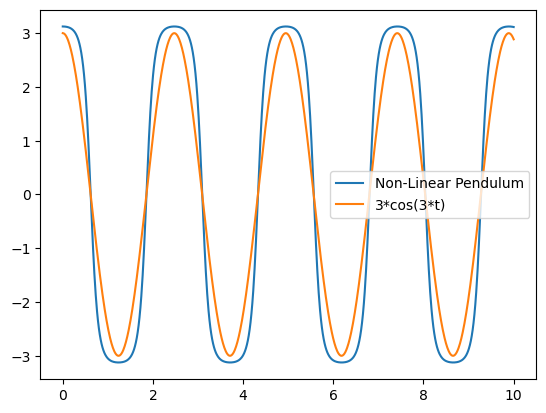

In [97]:

# Define the constants in the problem 
g = 9.81  # <- acceleration due to gravity 
l = 0.1   # <- length of the pendulum

# Define our system of differential equations 
def f(t, y):
    return  y[1] , - g / l * np.sin(y[0])

# Set the initial conditions 
init = [np.radians(179), 0]

# Define an array of times 
t = np.linspace(0, 10, 1000)

# Numerical solver ...
results = solve_ivp(f, (t[0], t[-1]), init, t_eval=t, rtol=1e-8)

# Plot 
plt.plot(results.t, results.y[0], label='Non-Linear Pendulum')

# The solution to the Non-Linear Pendulum is not quite the same shape as a cosine wave:
# - it is "squarer" at the top ...
plt.plot(t, 3*np.cos(2.541*t), label='~3*cos(2.5*t)')
plt.legend()
plt.show()

## Exercise (B)


Consider Van der Pol’s differential equation, 
\begin{equation}
    \frac{d^2x}{dt^2} - \mu(1-x^2)\frac{dx}{dt} + x = 0
\end{equation}

where $x$ is the dependent variable, $t$ is the independent variable (usually time), and $\mu$ is a parameter that indicates the nonlinearity and the strength of the damping in the system. 

This equation is widely used in various fields of physics and engineering, especially in the study of oscillatory systems.

Converting this second order differential equation into a set of multiple first-order ODEs, we get ...
 - Let 
   - $y[0](t) = x(t)$
   - $y[1](t) = \frac{dx}{dt}(t)$
 - Therefore
   - $\frac{dy[0]}{dt}(t) = \frac{dx}{dt}(t) = y[1](t)$
   - $\frac{dy[1]}{dt}(t) = \frac{d^2x}{d t^2}(t) = \mu(1-x^2)\frac{dx}{dt} - x = \mu(1-y[0]^2(t))y[1](t) - y[0](t)$
 
1. Define a function, `dydt`, that can be passed into `solve_ivp` to solve Van der Pol’s differential equation
2. Plot $y[0](t) = x(t)$ as a function of time for $\mu=0,1,2$, assuming $y[0](t=0)=1, y[1](t=0)=0$
3. Plot (y[0](t),y[1](t)) for $\mu=0,1,2$


N.B. If $\mu = 0$, we have a simple harmonic oscillator and the phase portrait (the $x,y$ plot) is simply a circle. For larger values of μ the solutions enter limiting cycles, but the cycles are more complicated than just circles. These limiting cycles are periodic attractors: every non-trivial solution converges to the limit cycle.

